##### Architecture:
- Input shape: 24 time steps 
- First LSTM layer with configurable neurons (tested: 25, 50, 100)
- Hidden Layers: Tested 2-4 total layers, with same neuron count
- Final single LSTM layer with same neuron count
- Output layer: Dense single neuron with linear activation function

##### Hyperparameters
- No. of layers: 2, 3, or 4
- Neurons per layer: 25, 50, or 100
- Best configuration: Selected based on lowest RMSE from CV (total 5 folds)

##### Evaluation Metrics
- RMSE (Root Mean Squared Error)
- MAPE (Mean Absolute Percentage Error)

##### Training
- Optimizer: Adam (default settings)
- Loss function: Mean Squared Error (MSE)
- Early stopping: Monitors validation loss with patience=10 epochs
- Batch size: 32
- Epochs: Up to 50 (with early stopping)

##### CV Setup
- CV1: Train 2015, Validate 2016
- CV2: Train 2015-2016, Validate 2017
- CV3: Train 2015-2017, Validate 2018
- CV4: Train 2015-2018, Validate 2019
- CV5: Train 2015-2019, Validate 2020

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')


In [15]:
LSTM_data =pd.read_csv (r"C:\Users\emran\Desktop\Kaggle_BENV0148\continuous dataset.csv", parse_dates=['datetime'], index_col='datetime')

In [16]:
# Explore the dataset
print("Data shape:", LSTM_data.shape)
print("\nData info:")
print(LSTM_data.info())
print("\nFirst few rows:")
print(LSTM_data.head())
print("\nColumn names:")
print(LSTM_data.columns.tolist())

Data shape: (48048, 16)

Data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48048 entries, 2015-01-03 01:00:00 to 2020-06-27 00:00:00
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   nat_demand  48048 non-null  float64
 1   T2M_toc     48048 non-null  float64
 2   QV2M_toc    48048 non-null  float64
 3   TQL_toc     48048 non-null  float64
 4   W2M_toc     48048 non-null  float64
 5   T2M_san     48048 non-null  float64
 6   QV2M_san    48048 non-null  float64
 7   TQL_san     48048 non-null  float64
 8   W2M_san     48048 non-null  float64
 9   T2M_dav     48048 non-null  float64
 10  QV2M_dav    48048 non-null  float64
 11  TQL_dav     48048 non-null  float64
 12  W2M_dav     48048 non-null  float64
 13  Holiday_ID  48048 non-null  int64  
 14  holiday     48048 non-null  int64  
 15  school      48048 non-null  int64  
dtypes: float64(13), int64(3)
memory usage: 6.2 MB
None

First few rows:
         

Data after preprocessing: (44543, 16)
                     nat_demand    T2M_toc  QV2M_toc   TQL_toc    W2M_toc  \
datetime                                                                    
2015-01-03 01:00:00    970.3450  25.865259  0.018576  0.016174  21.850546   
2015-01-03 02:00:00    912.1755  25.899255  0.018653  0.016418  22.166944   
2015-01-03 03:00:00    900.2688  25.937280  0.018768  0.015480  22.454911   
2015-01-03 04:00:00    889.9538  25.957544  0.018890  0.016273  22.110481   
2015-01-03 05:00:00    893.6865  25.973840  0.018981  0.017281  21.186089   

                       T2M_san  QV2M_san   TQL_san    W2M_san    T2M_dav  \
datetime                                                                   
2015-01-03 01:00:00  23.482446  0.017272  0.001855  10.328949  22.662134   
2015-01-03 02:00:00  23.399255  0.017265  0.001327  10.681517  22.578943   
2015-01-03 03:00:00  23.343530  0.017211  0.001428  10.874924  22.531030   
2015-01-03 04:00:00  23.238794  0.017128  

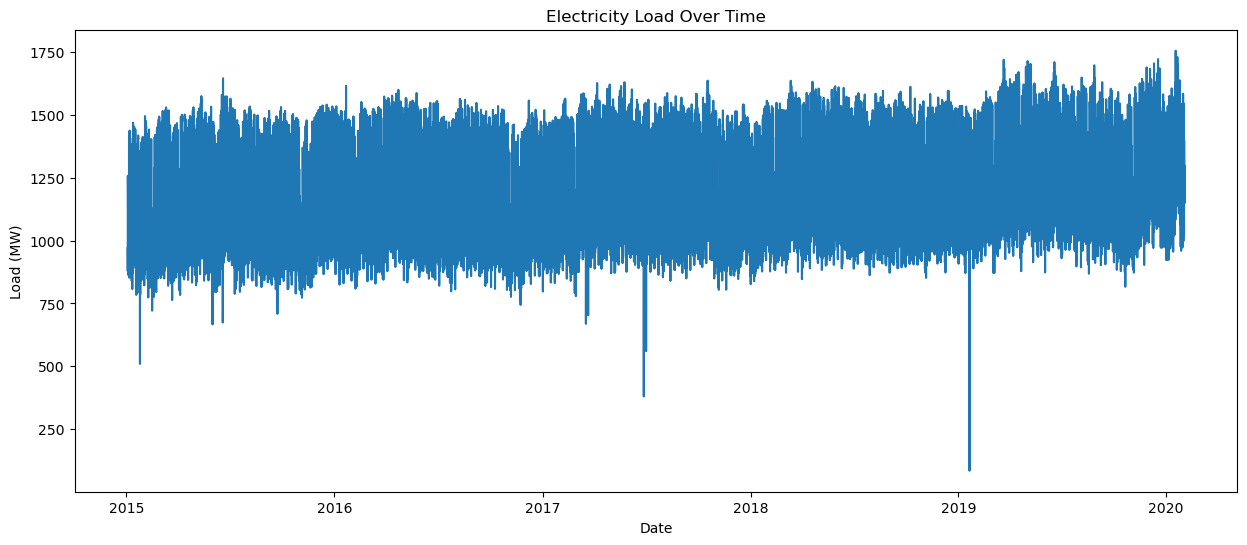

In [17]:
# Data Preprocessing
load_col = 'nat_demand'

LSTM_data[load_col] = LSTM_data[load_col].fillna(method='ffill').fillna(method='bfill')

start_date = '2015-01-01'
end_date = '2020-02-01'
LSTM_data = LSTM_data.loc[start_date:end_date]

print(f"Data after preprocessing: {LSTM_data.shape}")
print(LSTM_data.head())

plt.figure(figsize=(15, 6))
plt.plot(LSTM_data.index, LSTM_data[load_col])
plt.title('Electricity Load Over Time')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.show()

In [ ]:
# Define Cross-Validation splits
cv_splits = [
    {'train_years': [2015], 'val_year': 2016},
    {'train_years': [2015, 2016], 'val_year': 2017},
    {'train_years': [2015, 2016, 2017], 'val_year': 2018},
    {'train_years': [2015, 2016, 2017, 2018], 'val_year': 2019},
    {'train_years': [2015, 2016, 2017, 2018, 2019], 'val_year': 2020}
]

print("CV Splits:")
for i, cv in enumerate(cv_splits, 1):
    print(f"CV{i}: Train {cv['train_years']}, Validate {cv['val_year']}")

# Feature Engineering for LSTM
# Create sequences of 24 hours to predict next hour
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Scale the data
scaler = MinMaxScaler()
scaled_load = scaler.fit_transform(LSTM_data[[load_col]])

# Create sequences
seq_length = 24
X, y = create_sequences(scaled_load.flatten(), seq_length)

print(f"Sequences shape: X={X.shape}, y={y.shape}")

# Split data by years for CV
data_by_year = {}
for year in range(2015, 2021):
    mask = (LSTM_data.index.year == year)
    data_by_year[year] = scaled_load[mask]

print("Data points per year:")
for year, data in data_by_year.items():
    print(f"{year}: {len(data)}")

CV Splits:
CV1: Train [2015], Validate 2016
CV2: Train [2015, 2016], Validate 2017
CV3: Train [2015, 2016, 2017], Validate 2018
CV4: Train [2015, 2016, 2017, 2018], Validate 2019
CV5: Train [2015, 2016, 2017, 2018, 2019], Validate 2020
Sequences shape: X=(44519, 24), y=(44519,)
Data points per year:
2015: 8711
2016: 8784
2017: 8760
2018: 8760
2019: 8760
2020: 768


In [19]:
# Evaluation Functions
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100

def evaluate_model(y_true, y_pred):
    return {
        'RMSE': rmse(y_true, y_pred),
        'MAPE': mape(y_true, y_pred)
    }

# Function to get train/val data for a CV split
def get_cv_data(cv_split, data_by_year, seq_length=24):
    train_years = cv_split['train_years']
    val_year = cv_split['val_year']
    
    # Get training data
    train_data = np.concatenate([data_by_year[year].flatten() for year in train_years])
    
    # Create sequences for training
    X_train, y_train = create_sequences(train_data, seq_length)
    
    # Validation data
    val_data = data_by_year[val_year].flatten()
    X_val, y_val = create_sequences(val_data, seq_length)
    
    return X_train, y_train, X_val, y_val

In [20]:
# LSTM Model with 3 hidden layers
def create_lstm_model(seq_length, n_layers=3, n_neurons=50):
    model = Sequential()
    model.add(LSTM(n_neurons, return_sequences=True, input_shape=(seq_length, 1)))
    for _ in range(n_layers - 1):
        model.add(LSTM(n_neurons, return_sequences=True))
    model.add(LSTM(n_neurons))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# Train and evaluate LSTM
def train_evaluate_lstm(cv_split, data_by_year, seq_length=24, n_layers=3, n_neurons=50, epochs=50, batch_size=32):
    X_train, y_train, X_val, y_val = get_cv_data(cv_split, data_by_year, seq_length)
    
    # Reshape LSTM
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
    
    model = create_lstm_model(seq_length, n_layers, n_neurons)
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, 
                       validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)
    
    y_pred = model.predict(X_val)
    
    # Inverse transform
    y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred).flatten()
    
    metrics = evaluate_model(y_val_inv, y_pred_inv)
    
    return metrics, model

In [21]:
# Classical Models
def create_lagged_features(data, lags=24):
    df = pd.DataFrame(data, columns=['load'])
    for lag in range(1, lags+1):
        df[f'lag_{lag}'] = df['load'].shift(lag)
    df = df.dropna()
    return df

def train_evaluate_arima(cv_split, data_by_year):
    train_years = cv_split['train_years']
    val_year = cv_split['val_year']
    
    # Get training data
    train_data = np.concatenate([data_by_year[year].flatten() for year in train_years])
    train_data_inv = scaler.inverse_transform(train_data.reshape(-1, 1)).flatten()
    
    # Fit ARIMA
    model = ARIMA(train_data_inv, order=(5,1,0))  # Simple order, can be tuned
    model_fit = model.fit()
    
    # Validation data
    val_data = data_by_year[val_year].flatten()
    val_data_inv = scaler.inverse_transform(val_data.reshape(-1, 1)).flatten()
    
    # Forecast
    forecast = model_fit.forecast(steps=len(val_data_inv))
    
    # Evaluate
    metrics = evaluate_model(val_data_inv, forecast)
    
    return metrics

def train_evaluate_ml(cv_split, data_by_year, model_type='linear', lags=24):
    train_years = cv_split['train_years']
    val_year = cv_split['val_year']
    
    # Get training data
    train_data = np.concatenate([data_by_year[year].flatten() for year in train_years])
    train_df = create_lagged_features(train_data, lags)
    
    X_train = train_df.drop('load', axis=1)
    y_train = train_df['load']
    
    # Validation data
    val_data = data_by_year[val_year].flatten()
    val_df = create_lagged_features(val_data, lags)
    
    X_val = val_df.drop('load', axis=1)
    y_val = val_df['load']
    
    # Model
    if model_type == 'linear':
        model = LinearRegression()
    elif model_type == 'rf':
        model = RandomForestRegressor(n_estimators=100, random_state=42)
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_val)
    
    # Inverse transform
    y_val_inv = scaler.inverse_transform(y_val.values.reshape(-1, 1)).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    
    # Evaluate
    metrics = evaluate_model(y_val_inv, y_pred_inv)
    
    return metrics

In [22]:
# Run Experiments
results = {}

for i, cv in enumerate(cv_splits, 1):
    print(f"Running CV{i}: Train {cv['train_years']}, Validate {cv['val_year']}")
    
    # LSTM
    print("Training LSTM...")
    lstm_metrics, _ = train_evaluate_lstm(cv, data_by_year)
    results[f'CV{i}_LSTM'] = lstm_metrics
    
    # ARIMA
    print("Training ARIMA...")
    arima_metrics = train_evaluate_arima(cv, data_by_year)
    results[f'CV{i}_ARIMA'] = arima_metrics
    
    # Linear Regression
    print("Training Linear Regression...")
    lr_metrics = train_evaluate_ml(cv, data_by_year, 'linear')
    results[f'CV{i}_Linear'] = lr_metrics
    
    # Random Forest
    print("Training Random Forest...")
    rf_metrics = train_evaluate_ml(cv, data_by_year, 'rf')
    results[f'CV{i}_RF'] = rf_metrics
    
    print(f"CV{i} Results:")
    for model, metrics in [('LSTM', lstm_metrics), ('ARIMA', arima_metrics), ('Linear', lr_metrics), ('RF', rf_metrics)]:
        print(f"  {model}: RMSE={metrics['RMSE']:.2f}, MAPE={metrics['MAPE']:.2f}%")
    print()

# Summary
print("Summary of Results:")
for model in ['LSTM', 'ARIMA', 'Linear', 'RF']:
    rmse_vals = [results[f'CV{i}_{model}']['RMSE'] for i in range(1,6)]
    mape_vals = [results[f'CV{i}_{model}']['MAPE'] for i in range(1,6)]
    print(f"{model}: Avg RMSE={np.mean(rmse_vals):.2f}, Avg MAPE={np.mean(mape_vals):.2f}%")

Running CV1: Train [2015], Validate 2016
Training LSTM...
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Training ARIMA...
Training Linear Regression...
Training Random Forest...
CV1 Results:
  LSTM: RMSE=23.20, MAPE=1.49%
  ARIMA: RMSE=194.38, MAPE=13.99%
  Linear: RMSE=30.60, MAPE=1.98%
  RF: RMSE=21.15, MAPE=1.32%

Running CV2: Train [2015, 2016], Validate 2017
Training LSTM...
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Training ARIMA...
Training Linear Regression...
Training Random Forest...
CV2 Results:
  LSTM: RMSE=30.60, MAPE=1.62%
  ARIMA: RMSE=222.40, MAPE=14.19%
  Linear: RMSE=38.05, MAPE=2.05%
  RF: RMSE=27.71, MAPE=1.37%

Running CV3: Train [2015, 2016, 2017], Validate 2018
Training LSTM...
273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Training ARIMA...
Training Linear Regression...
Training Random Forest...
CV3 Results:
  LSTM: RMSE=18.73, MAPE=1.15%
  ARIMA: RMSE=297.19, MAPE=18.09%
  Linear: RMSE=30.38, MAPE=1.89%
  RF: RMSE=20.05, MAPE=1.19%

Running CV4: Train [2015, 2016, 2017, 20

Testing 2 layers, 25 neurons
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Testing 2 layers, 50 neurons
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Testing 2 layers, 100 neurons
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Testing 3 layers, 25 neurons
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Testing 3 layers, 50 neurons
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Testing 3 layers, 100 neurons
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step
Testing 4 layers, 25 neurons
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Testing 4 layers, 50 neurons
274/274 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Testing 4 layers, 100 neurons
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
Best configuration: 4 layers, 25 neurons
Best RMSE: 28.48, MAPE: 1.93%


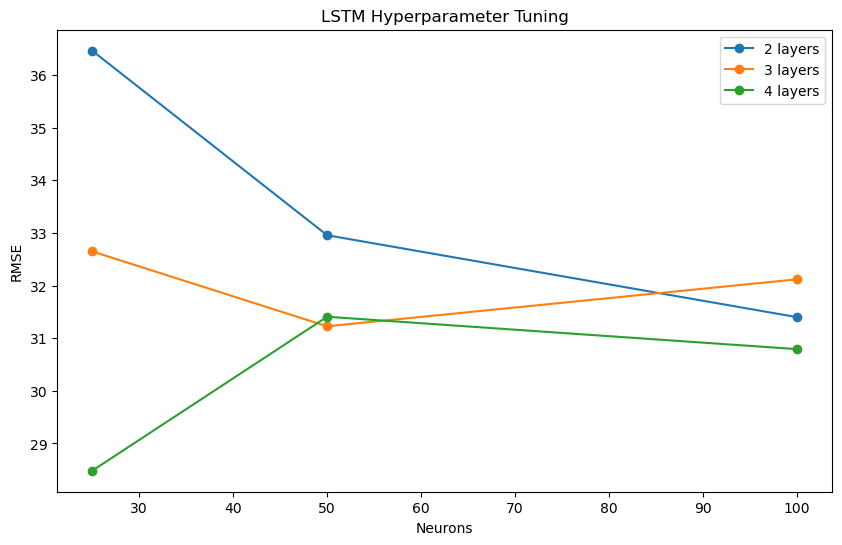

In [23]:
# Hyperparameter Tuning for LSTM
# Test different number of layers and neurons
layer_options = [2, 3, 4]
neuron_options = [25, 50, 100]

tuning_results = []

for n_layers in layer_options:
    for n_neurons in neuron_options:
        print(f"Testing {n_layers} layers, {n_neurons} neurons")
        
        # Use CV1 for tuning
        cv = cv_splits[0]
        metrics, _ = train_evaluate_lstm(cv, data_by_year, n_layers=n_layers, n_neurons=n_neurons, epochs=20)
        
        tuning_results.append({
            'layers': n_layers,
            'neurons': n_neurons,
            'RMSE': metrics['RMSE'],
            'MAPE': metrics['MAPE']
        })

# Find best configuration
best_config = min(tuning_results, key=lambda x: x['RMSE'])
print(f"Best configuration: {best_config['layers']} layers, {best_config['neurons']} neurons")
print(f"Best RMSE: {best_config['RMSE']:.2f}, MAPE: {best_config['MAPE']:.2f}%")

# Plot tuning results
layers = [r['layers'] for r in tuning_results]
neurons = [r['neurons'] for r in tuning_results]
rmse = [r['RMSE'] for r in tuning_results]

plt.figure(figsize=(10, 6))
for l in layer_options:
    layer_data = [r for r in tuning_results if r['layers'] == l]
    plt.plot([r['neurons'] for r in layer_data], [r['RMSE'] for r in layer_data], marker='o', label=f'{l} layers')
plt.xlabel('Neurons')
plt.ylabel('RMSE')
plt.title('LSTM Hyperparameter Tuning')
plt.legend()
plt.show()

In [11]:
# Check all columns
print("All columns:", LSTM_data.columns.tolist())
print("\nData types:")
print(LSTM_data.dtypes)

All columns: ['nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school']

Data types:
nat_demand    float64
T2M_toc       float64
QV2M_toc      float64
TQL_toc       float64
W2M_toc       float64
T2M_san       float64
QV2M_san      float64
TQL_san       float64
W2M_san       float64
T2M_dav       float64
QV2M_dav      float64
TQL_dav       float64
W2M_dav       float64
Holiday_ID      int64
holiday         int64
school          int64
dtype: object


In [12]:
print('datetime' in LSTM_data.columns)
if 'datetime' in LSTM_data.columns:
    print("Datetime column exists")
    print(LSTM_data['datetime'].head())
else:
    print("No datetime column")

False
No datetime column


In [13]:
print("Index:", LSTM_data.index)
print("Index type:", type(LSTM_data.index))
print("Index name:", LSTM_data.index.name)

Index: DatetimeIndex(['2015-01-03 01:00:00', '2015-01-03 02:00:00',
               '2015-01-03 03:00:00', '2015-01-03 04:00:00',
               '2015-01-03 05:00:00', '2015-01-03 06:00:00',
               '2015-01-03 07:00:00', '2015-01-03 08:00:00',
               '2015-01-03 09:00:00', '2015-01-03 10:00:00',
               ...
               '2020-06-26 15:00:00', '2020-06-26 16:00:00',
               '2020-06-26 17:00:00', '2020-06-26 18:00:00',
               '2020-06-26 19:00:00', '2020-06-26 20:00:00',
               '2020-06-26 21:00:00', '2020-06-26 22:00:00',
               '2020-06-26 23:00:00', '2020-06-27 00:00:00'],
              dtype='datetime64[ns]', name='datetime', length=48048, freq=None)
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index name: datetime
